![Nuclio logo](https://nuclio.school/wp-content/uploads/2018/12/nucleoDS-newBlack.png)

# Proyecto final - Data Analytics y Business Intelligence

Recibimos dos datasets:

1. `renfe.csv`: Información de búsquedas de billetes que se hicieron en la página de Renfe.
2. `coordenadas_ciudades.csv`: Latitud y longitud de provincias españolas.

Queremos usar estos datasets para un modelo de Machine Learning que utilizaremos para predecir los precios de los billetes. Y, para ello, necesitamos limpiar, explorar y pre-procesar el dataset.

## Reglas de juego

1. El proyecto se debe entregar en grupos de dos o individualmente. 
2. Cada respuesta correcta suma un punto.
3. La calificación final consistirá en la suma de todos los puntos obtenidos sobre el total de puntos posibles.


## Diccionario de datos

Esta es la información provista:

### `renfe.csv`
- `FECHA_CONSULTA`: Fecha en la que se consultó la página.
- `FECHA_INICIO`: Fecha de inicio del trayecto.
- `FECHA_FIN`: Fecha de finalización del trayecto.
- `CIUDAD_ORIGEN`: Ciudad de origen del trayecto.
- `CIUDAD_DESTINO`: Ciudad destino del trayecto.
- `TIPO_TREN`: Tipo de tren.
- `TIPO_TARIFA`: Tipo de tarifa del billete.
- `CLASE`: Clase del asiento seleccionado.
- `PRECIO`: Precio del tren seleccionado.

### `coordenadas_ciudades.csv`
- `ciudad`: Nombre de la ciudad.
- `latitud`: Coordenada de latitud de la ciudad.
- `longitud`: Coordenada de longitud de la ciudad.

## Importar librerías

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.float_format', lambda x: '%.2f' % x)

## P0: Lee el dataset `renfe.csv`

In [44]:
df = pd.read_csv('renfe.csv', sep=';')


## P1: Visualiza las primeras y las últimas filas del dataset

In [45]:
df.head()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75


In [46]:
df.tail()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
383563,2019-05-06 05:11:53,2019-05-10 19:40:00,2019-05-10 21:29:00,MADRID,VALENCIA,AVE,Flexible,Turista,73.10
383564,2019-06-19 21:48:56,2019-08-05 20:00:00,2019-08-05 23:10:00,BARCELONA,MADRID,AVE,Promo,Preferente,54.45
383565,2019-04-24 23:21:44,2019-04-29 16:15:00,2019-04-29 17:55:00,VALENCIA,MADRID,AVE,Promo,Turista,27.80
383566,2019-05-27 21:05:19,2019-07-07 15:00:00,2019-07-07 17:21:00,MADRID,SEVILLA,AVE,Promo,Turista,47.30
383567,2019-05-27 15:04:14,2019-06-16 18:35:00,2019-06-16 20:21:00,VALENCIA,MADRID,AVE,Flexible,Turista,73.10


## P2: ¿Cuantas filas y columnas tiene el dataset?

In [47]:
df.shape

(383568, 9)

## P3: Cambia los nombres de todas las columnas a minúsculas

In [48]:
df.columns = df.columns.str.lower()

## P4: Muestra los tipos de datos de cada columna

In [49]:
df.dtypes

fecha_consulta     object
fecha_inicio       object
fecha_fin          object
ciudad_origen      object
ciudad_destino     object
tipo_tren          object
tipo_tarifa        object
clase              object
precio            float64
dtype: object

## P5: Cambia los tipos de datos que creas que creas incorrectos, por los tipos adecuados

In [50]:
columnas_fecha = ['fecha_consulta', 'fecha_inicio', 'fecha_fin']
for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col])

In [51]:
df.dtypes

fecha_consulta    datetime64[ns]
fecha_inicio      datetime64[ns]
fecha_fin         datetime64[ns]
ciudad_origen             object
ciudad_destino            object
tipo_tren                 object
tipo_tarifa               object
clase                     object
precio                   float64
dtype: object

## P6: Filas duplicadas

### P6.1: ¿Cuántas filas duplicadas tiene el dataset?

In [52]:
total_duplicados = df.duplicated().sum()
print(f"El número total de filas duplicadas en el dataset es: {total_duplicados}")

El número total de filas duplicadas en el dataset es: 33


### P6.2: Quita las filas duplicadas

In [53]:
df = df.drop_duplicates()

In [54]:
df.shape

(383535, 9)

## P7: Valores nulos y análisis de `precio`

### P7.1: ¿Que porcentaje de valores nulos hay por cada columna?

In [55]:
porcentaje_nulos = df.isnull().mean() * 100
print("El porcentaje de nulos por columna es:\n",porcentaje_nulos.apply(lambda x: f"{x:.2f} %"))

El porcentaje de nulos por columna es:
 fecha_consulta    0.00 %
fecha_inicio      0.00 %
fecha_fin         0.00 %
ciudad_origen     0.00 %
ciudad_destino    0.00 %
tipo_tren         0.00 %
tipo_tarifa       0.35 %
clase             0.35 %
precio            7.43 %
dtype: object


### P7.2: ¿Cual es el mínimo, percentiles importantes (25%, 50%, 75%) y el máximo de `precio`?

In [56]:
df["precio"].describe()

count   355020.00
mean        61.44
std         25.70
min          0.00
25%         41.20
50%         58.15
75%         76.30
max        342.80
Name: precio, dtype: float64

### P7.3: ¿Hay algo raro en el valor mínimo de `precio`? Quita las filas con ese valor del dataset

In [57]:
cantidad = (df['precio'] == 0).sum()
print(f"Hay {cantidad} billetes con precio 0€.")

Hay 2 billetes con precio 0€.


In [58]:
df = df[df['precio'] != 0]

In [59]:
df.precio.min()

12.85

### P7.4: Reemplaza los valores nulos en `precio` por la media de esa columna

In [60]:
precio_medio = df['precio'].mean()
df['precio'] = df['precio'].fillna(precio_medio)

### P7.5: Quita las filas donde `clase` o `tipo_tarifa` sean nulos

In [61]:
df = df.dropna(subset=['clase', 'tipo_tarifa'])

## P8: Tiempo de viaje

### P8.1: Calcula el tiempo de viaje en minutos (fecha_fin - fecha_inicio)

In [62]:
tiempo_de_viaje = df['fecha_fin'] - df['fecha_inicio']
df['tiempo_viaje_minutos'] = tiempo_de_viaje.dt.total_seconds() / 60

### P8.2: Haz un histograma de la variable que acabas de crear (`tiempo_de_viaje`)

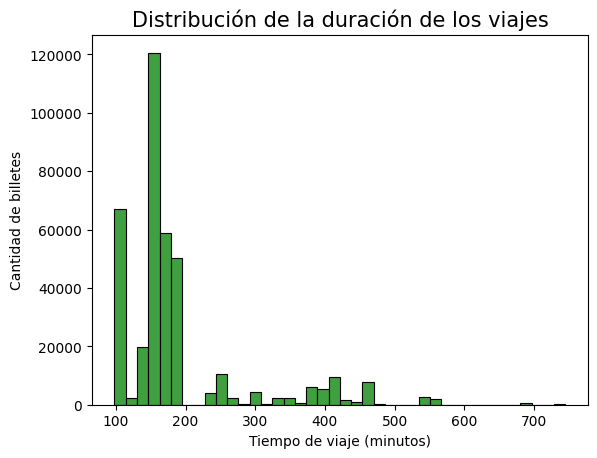

In [81]:
sns.histplot(data=df, x='tiempo_viaje_minutos', bins=40, color='green')
plt.title('Distribución de la duración de los viajes', fontsize=15)
plt.xlabel('Tiempo de viaje (minutos)', fontsize=10)
plt.ylabel('Cantidad de billetes', fontsize=10)
plt.show()

## P9: Extrae el día, el nombre del día, el mes y la hora de `fecha_inicio`

In [64]:
df['dia'] = df['fecha_inicio'].dt.day
df['dia_semana'] = df['fecha_inicio'].dt.day_name()
df['mes'] = df['fecha_inicio'].dt.month
df['hora'] = df['fecha_inicio'].dt.strftime('%H:%M')

In [65]:
df.head()

,fecha_consulta,fecha_inicio,fecha_fin,ciudad_origen,ciudad_destino,tipo_tren,tipo_tarifa,clase,precio,tiempo_viaje_minutos,dia,dia_semana,mes,hora
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.00,28,Friday,6,20:36
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.00,14,Sunday,7,10:00
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.00,23,Thursday,5,13:40
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.00,29,Wednesday,5,14:50
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.00,26,Wednesday,6,13:25


## P10: Quita las columnas `fecha_consulta`, `fecha_inicio` y `fecha_fin` del dataset

In [66]:
columnas_eliminar = ['fecha_consulta', 'fecha_inicio', 'fecha_fin']
df = df.drop(columns=columnas_eliminar)
df.head()

,ciudad_origen,ciudad_destino,tipo_tren,tipo_tarifa,clase,precio,tiempo_viaje_minutos,dia,dia_semana,mes,hora
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.00,28,Friday,6,20:36
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.00,14,Sunday,7,10:00
2,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.00,23,Thursday,5,13:40
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.00,29,Wednesday,5,14:50
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.00,26,Wednesday,6,13:25


## P11: Lee el dataset `coordenadas_ciudades.csv` y únelo con al dataset que has procesado hasta ahora (utiliza `ciudad_destino` para el `join`)

In [67]:
df_coordenadas = pd.read_csv('coordenadas_ciudades.csv')

In [68]:
df_coordenadas = df_coordenadas.set_index('ciudad')
df = df.join(df_coordenadas, on='ciudad_destino')
df.head(2)

,ciudad_origen,ciudad_destino,tipo_tren,tipo_tarifa,clase,precio,tiempo_viaje_minutos,dia,dia_semana,mes,hora,latitud,longitud
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.00,28,Friday,6,20:36,40.42,-3.70
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.00,14,Sunday,7,10:00,40.42,-3.70


## P12: Gráfica en un mapa el precio medio por ciudad de destino

In [69]:
df_mapa = df.groupby('ciudad_destino')[['precio', 'latitud', 'longitud']].mean().reset_index()
fig = px.scatter_mapbox(df_mapa,
                        lat='latitud',
                        lon='longitud',
                        size='precio',
                        hover_name='ciudad_destino',
                        hover_data={'latitud':False, 'longitud':False, 'precio':':.2f'},
                        color_discrete_sequence=['green'],
                        zoom=4.6,
                        height=600,
                        width=800,
                        title='Precio medio de cada billete por ciudad de destino',
                        mapbox_style="open-street-map")
fig.show()

C:\Users\Danie\AppData\Local\Temp\ipykernel_1100\3218477391.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## P13: Haz una tabla de correlación, ¿hay variables númericas correladas con el precio?

In [70]:
correlaciones = df.corr(numeric_only=True)
tabla_precio = correlaciones[['precio']].sort_values(by='precio')
print(tabla_precio)

                      precio
tiempo_viaje_minutos   -0.23
mes                    -0.18
dia                     0.03
latitud                 0.22
longitud                0.24
precio                  1.00


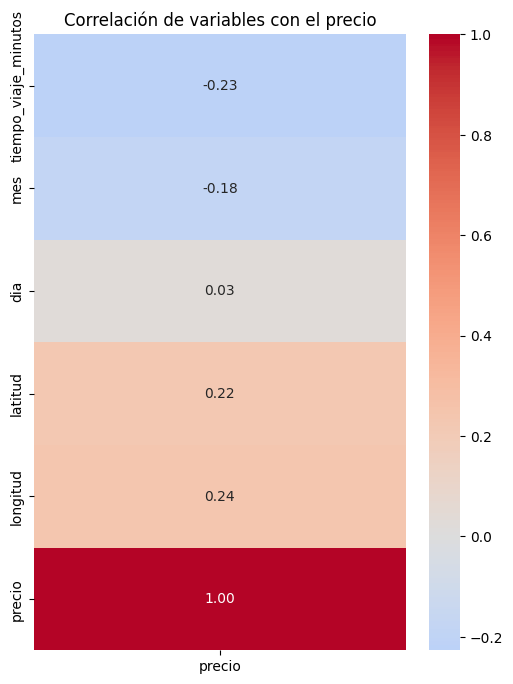

In [71]:
plt.figure(figsize=(6, 8))
sns.heatmap(
    tabla_precio,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)
plt.title("Correlación de variables con el precio")
plt.show()

## Conclusión
- No he encontrado ninguna variable numérica con una correlación fuerte (superior a 0.5) con el precio.
- Las variables de ubicación (latitud y longitud) y duración del viaje muestran una relación débil.
- Estos resultados indican que el precio del billete depende principalmente de otros factores no numéricos (probablemente la Clase, el Tipo de Tarifa o el Tipo de Tren)

## P14: Relación entre variables del dataset y `precio`

### P14.1: Haz un scatter plot de precio vs. tiempo de viaje

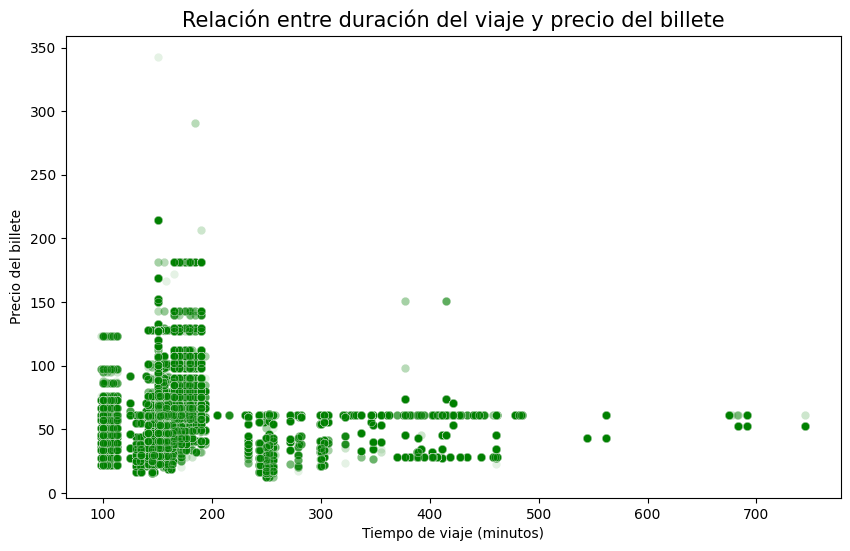

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tiempo_viaje_minutos', y='precio', color='green', alpha=0.1)
plt.title('Relación entre duración del viaje y precio del billete', fontsize=15)
plt.xlabel('Tiempo de viaje (minutos)', fontsize=10)
plt.ylabel('Precio del billete', fontsize=10)
plt.show()

In [73]:
columnas_categoricas = ['ciudad_origen', 'ciudad_destino', 'tipo_tren', 'tipo_tarifa', 'clase', 'dia_semana']
df_encoded = pd.get_dummies(df, columns=columnas_categoricas)
correlaciones_trenes = df_encoded.corr(numeric_only=True)
analisis_velocidad = correlaciones_trenes['tiempo_viaje_minutos'].filter(like='tipo_tren').sort_values()
analisis_velocidad

tipo_tren_AVE         -0.60
tipo_tren_ALVIA       -0.05
tipo_tren_INTERCITY   -0.04
tipo_tren_AV City     -0.03
tipo_tren_AVE-TGV     -0.01
tipo_tren_LD-AVE       0.07
tipo_tren_MD-AVE       0.07
tipo_tren_AVE-LD       0.11
tipo_tren_AVE-MD       0.15
tipo_tren_LD           0.17
tipo_tren_LD-MD        0.18
tipo_tren_MD           0.22
tipo_tren_TRENHOTEL    0.23
tipo_tren_MD-LD        0.26
tipo_tren_R. EXPRES    0.43
tipo_tren_REGIONAL     0.56
Name: tiempo_viaje_minutos, dtype: float64

## Conclusión:
Viendo los resultados iniciales de la gráfica, he obtado por hace una correlación entre *tipo de tren* y *tiempo de viaje*, en el que se aprecia que los trenes que menos tiempo tardan son los de Alta Velocidad (AVE), lo que junto a la gráfica de *duración de viaje* y *precio*, nos permite llegar a la conclusion que **la variedad de precios se produce en billetes de trenes de Alta Velocidad**. 

Esto nos permite saber que el principal factor para establecer el precio no es el tiempo de viaje ya que dentro de una misma duración de viaje, existe una dispersión de precios enorme, lo que indica que variables categóricas como la Clase, o el Tipo de Tren, o la Tarifa son determinantes para el precio final.

### P14.2: Haz un boxplot de precio vs. dia de la semana

In [74]:
orden_de_dia = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

C:\Users\Danie\AppData\Local\Temp\ipykernel_1100\1058447014.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




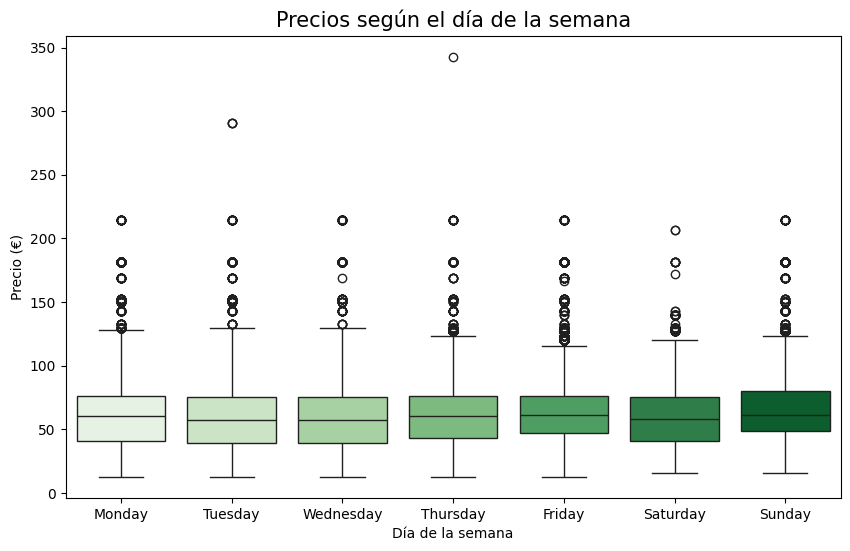

In [75]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dia_semana', y='precio', order=orden_de_dia, palette='Greens')
plt.title('Precios según el día de la semana', fontsize=15)
plt.xlabel('Día de la semana', fontsize=10)
plt.ylabel('Precio (€)', fontsize=10)
plt.show()

## Conclusión
El análisis de la distribución muestra que no existe una diferencia drástica de precios en dependecia del dia de la semana, la gran dispersión de precios sugiere que el día de la semana no es el único factor determinante, y que es posible encontrar tarifas de precios similares cualquier día.

### P14.3: Gráfica el precio medio por día de la semana

In [76]:
precio_medio = df.groupby('dia_semana')['precio'].mean().reindex(orden_de_dia)

print("Precios medios por día:")
print(precio_medio)

Precios medios por día:
dia_semana
Monday      61.05
Tuesday     58.02
Wednesday   59.15
Thursday    60.75
Friday      65.38
Saturday    57.91
Sunday      67.22
Name: precio, dtype: float64


C:\Users\Danie\AppData\Local\Temp\ipykernel_1100\3404175502.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




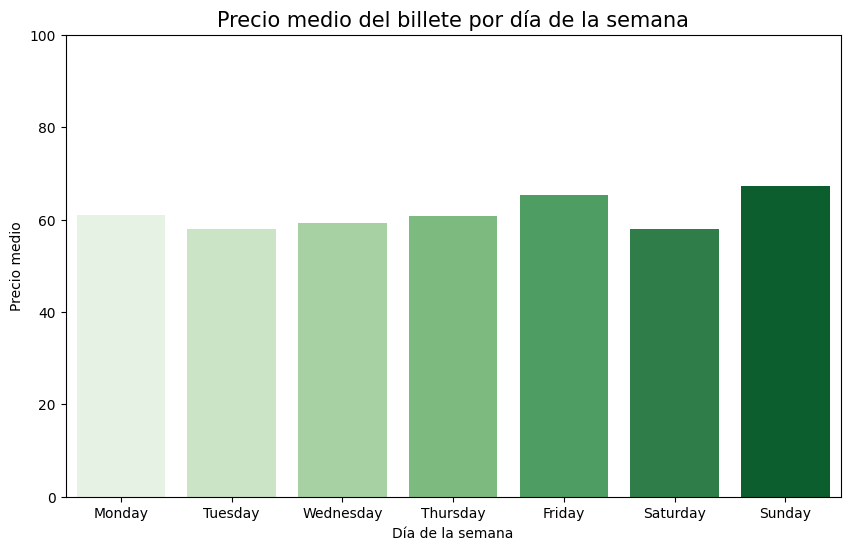

In [77]:
plt.figure(figsize=(10, 6))
sns.barplot(x=precio_medio.index, y=precio_medio.values, palette='Greens')
plt.title('Precio medio del billete por día de la semana', fontsize=15)
plt.xlabel('Día de la semana', fontsize=10)
plt.ylabel('Precio medio', fontsize=10)
plt.ylim(0, 100)

plt.show()


## Conclusión
- La gráfica permite observar cómo el precio medio es mayor los viernes y domingos. Estos corresponden claramente a los días clave del 'viaje de fin de semana' (ida y vuelta), siendo el sábado notablemente más barato que estos días adyacentes.
- Esto demuestra que la variabilidad de precios afecta principalmente a los trenes de Alta Velocidad (asociados a ocio y turismo), a diferencia de los trayectos regionales o de Cercanias, que suelen utilizarse en días laborables para desplazamientos de trabajo o estudio y mantienen precios más constantes.

## P15: Crea un nuevo dataframe donge apliques *one-hot-encoding* a las variables categoricas

In [78]:
columnas_categoricas = ['ciudad_origen', 'ciudad_destino', 'tipo_tren', 'tipo_tarifa', 'clase', 'dia_semana']
df_encoded = pd.get_dummies(df, columns=columnas_categoricas)
df_encoded.head()

,precio,tiempo_viaje_minutos,dia,mes,hora,latitud,longitud,ciudad_origen_BARCELONA,ciudad_origen_MADRID,ciudad_origen_PONFERRADA,...,clase_Turista PlusSólo plaza H,clase_Turista con enlace,clase_TuristaSólo plaza H,dia_semana_Friday,dia_semana_Monday,dia_semana_Saturday,dia_semana_Sunday,dia_semana_Thursday,dia_semana_Tuesday,dia_semana_Wednesday
0,67.20,158.00,28,6,20:36,40.42,-3.70,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,107.70,190.00,14,7,10:00,40.42,-3.70,True,False,False,...,False,False,False,False,False,False,True,False,False,False
2,47.30,150.00,23,5,13:40,40.42,-3.70,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,28.35,460.00,29,5,14:50,40.42,-3.70,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,66.75,179.00,26,6,13:25,41.38,2.18,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [79]:
print("Dimensiones del antiguo DataFrame:", df.shape)
print("Dimensiones del nuevo DataFrame:", df_encoded.shape)


Dimensiones del antiguo DataFrame: (382195, 13)
Dimensiones del nuevo DataFrame: (382195, 58)
